In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

### Exploration and Data loading

In [100]:
df = pd.read_csv('../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv')
df.head(1)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No


In [3]:
pd.set_option('display.max_columns',None)# show all columns in the dataframe
pd.set_option('display.max_rows',None)# show all rows in the dataframe

In [4]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [101]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
df.describe(include='all')

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
count,7043,7043,7043.000000,7043,7043,7043.000000,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043.000000,7043,7043
unique,7043,2,NaN,2,2,NaN,2,3,3,3,3,3,3,3,3,3,2,4,NaN,6531,2
top,7590-VHVEG,Male,NaN,No,No,NaN,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,NaN,20.2,No
freq,1,3555,NaN,3641,4933,NaN,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,NaN,11,5174
mean,NaN,NaN,0.162147,NaN,NaN,32.371149,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.761692,NaN,NaN
std,NaN,NaN,0.368612,NaN,NaN,24.559481,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.090047,NaN,NaN
min,NaN,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.250000,NaN,NaN
25%,NaN,NaN,0.000000,NaN,NaN,9.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.500000,NaN,NaN
50%,NaN,NaN,0.000000,NaN,NaN,29.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.350000,NaN,NaN
75%,NaN,NaN,0.000000,NaN,NaN,55.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.850000,NaN,NaN


--> based on the describe, we can see that most categorical values have between 2,3 or 4 categories

--> so for those that have only 2(binary) lets replace by 0 and 1

-->for those that have 3 or 4, we can do one-hot encoding

### Binary Encoding

In [13]:
def get_binary_columns(columns):
    res=[]
    for col in columns:
        unique_vals = df[col].unique()
        if len(unique_vals)==2:
            res.append(col)
        else:
            continue
    return res
binary_cols = get_binary_columns(df.columns)
print(binary_cols)

['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn']


In [14]:
df[binary_cols] = df[binary_cols].replace({
    'Yes':1,'No':0,
    'Male':1,'Female':0
})

C:\Windows\Temp\ipykernel_47444\2404202100.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[binary_cols] = df[binary_cols].replace({


In [15]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,0,0,1,0,1,0,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,1,Electronic check,29.85,29.85,0
1,5575-GNVDE,1,0,0,0,34,1,No,DSL,Yes,No,Yes,No,No,No,One year,0,Mailed check,56.95,1889.5,0
2,3668-QPYBK,1,0,0,0,2,1,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,1,Mailed check,53.85,108.15,1
3,7795-CFOCW,1,0,0,0,45,0,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,0,Bank transfer (automatic),42.30,1840.75,0
4,9237-HQITU,0,0,0,0,2,1,No,Fiber optic,No,No,No,No,No,No,Month-to-month,1,Electronic check,70.70,151.65,1


### One hot encoding

In [17]:

mult_cols =  ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 
              'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
                'Contract', 'PaymentMethod']
df =pd.get_dummies(df,columns=mult_cols,drop_first=True)

In [18]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,7590-VHVEG,0,0,1,0,1,0,1,29.85,29.85,0,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False
1,5575-GNVDE,1,0,0,0,34,1,0,56.95,1889.5,0,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,True,False,False,False,True
2,3668-QPYBK,1,0,0,0,2,1,1,53.85,108.15,1,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True
3,7795-CFOCW,1,0,0,0,45,0,0,42.30,1840.75,0,True,False,False,False,False,True,False,False,False,True,False,True,False,False,False,False,True,False,False,False,False
4,9237-HQITU,0,0,0,0,2,1,1,70.70,151.65,1,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False


### Cleaning

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 32 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   customerID                             7043 non-null   object 
 1   gender                                 7043 non-null   int64  
 2   SeniorCitizen                          7043 non-null   int64  
 3   Partner                                7043 non-null   int64  
 4   Dependents                             7043 non-null   int64  
 5   tenure                                 7043 non-null   int64  
 6   PhoneService                           7043 non-null   int64  
 7   PaperlessBilling                       7043 non-null   int64  
 8   MonthlyCharges                         7043 non-null   float64
 9   TotalCharges                           7043 non-null   object 
 10  Churn                                  7043 non-null   int64  
 11  Mult

In [21]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'],errors='coerce')

In [22]:
df = df.drop('customerID',axis=1)

In [23]:
bool_cols = df.select_dtypes(include='bool').columns
bool_cols

Index(['MultipleLines_No phone service', 'MultipleLines_Yes',
       'InternetService_Fiber optic', 'InternetService_No',
       'OnlineSecurity_No internet service', 'OnlineSecurity_Yes',
       'OnlineBackup_No internet service', 'OnlineBackup_Yes',
       'DeviceProtection_No internet service', 'DeviceProtection_Yes',
       'TechSupport_No internet service', 'TechSupport_Yes',
       'StreamingTV_No internet service', 'StreamingTV_Yes',
       'StreamingMovies_No internet service', 'StreamingMovies_Yes',
       'Contract_One year', 'Contract_Two year',
       'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check'],
      dtype='object')

In [24]:
df[bool_cols] = df[bool_cols].astype(int)

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 31 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   gender                                 7043 non-null   int64  
 1   SeniorCitizen                          7043 non-null   int64  
 2   Partner                                7043 non-null   int64  
 3   Dependents                             7043 non-null   int64  
 4   tenure                                 7043 non-null   int64  
 5   PhoneService                           7043 non-null   int64  
 6   PaperlessBilling                       7043 non-null   int64  
 7   MonthlyCharges                         7043 non-null   float64
 8   TotalCharges                           7032 non-null   float64
 9   Churn                                  7043 non-null   int64  
 10  MultipleLines_No phone service         7043 non-null   int64  
 11  Mult

In [26]:
corr_matrix = df.corr(numeric_only=True)
churn_corr = corr_matrix['Churn'].sort_values(ascending=False)
print(churn_corr)

Churn                                    1.000000
InternetService_Fiber optic              0.308020
PaymentMethod_Electronic check           0.301919
MonthlyCharges                           0.193356
PaperlessBilling                         0.191825
SeniorCitizen                            0.150889
StreamingTV_Yes                          0.063228
StreamingMovies_Yes                      0.061382
MultipleLines_Yes                        0.040102
PhoneService                             0.011942
gender                                  -0.008612
MultipleLines_No phone service          -0.011942
DeviceProtection_Yes                    -0.066160
OnlineBackup_Yes                        -0.082255
PaymentMethod_Mailed check              -0.091683
PaymentMethod_Credit card (automatic)   -0.134302
Partner                                 -0.150448
Dependents                              -0.164221
TechSupport_Yes                         -0.164674
OnlineSecurity_Yes                      -0.171226


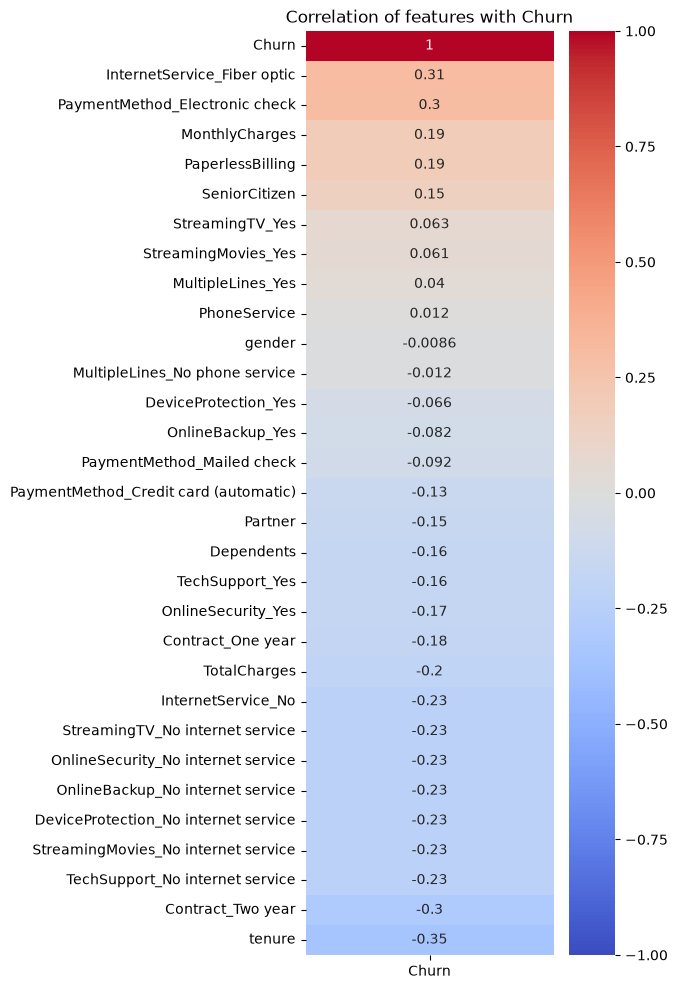

In [35]:
corr_matrix = df.corr(numeric_only=True)
churn_corr = corr_matrix[['Churn']].sort_values(by='Churn',ascending=False)
plt.figure(figsize=(4,12))
sns.heatmap(churn_corr,annot=True,cmap='coolwarm',vmin=-1,vmax=1)
plt.title('Correlation of features with Churn')
plt.show()

Negative (lower values->less likely to churn):

-tenure->Customers who stay longer are less likely to churn

-Contract_two_year

-Contract_one_year

Positive(higher values->more likely to churn):

-InternetService_Fiber option

-PaymentMethod_Electronic check

### Look for Multicolinearity (VIF)

In [37]:
churn_corr 

,Churn
Churn,1.000000
InternetService_Fiber optic,0.308020
PaymentMethod_Electronic check,0.301919
MonthlyCharges,0.193356
PaperlessBilling,0.191825
SeniorCitizen,0.150889
StreamingTV_Yes,0.063228
StreamingMovies_Yes,0.061382
MultipleLines_Yes,0.040102
PhoneService,0.011942


In [38]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,1,29.85,29.85,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0
1,1,0,0,0,34,1,0,56.95,1889.50,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,1,0,0,0,1
2,1,0,0,0,2,1,1,53.85,108.15,1,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1
3,1,0,0,0,45,0,0,42.30,1840.75,0,1,0,0,0,0,1,0,0,0,1,0,1,0,0,0,0,1,0,0,0,0
4,0,0,0,0,2,1,1,70.70,151.65,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0


In [ ]:
## collapsing redundant features before running VIF
df['No_internet_service'] = (
   df['StreamingTV_No internet service'] |
df['OnlineSecurity_No internet service'] |
df['OnlineBackup_No internet service'] |
df['DeviceProtection_No internet service'] |
df['StreamingMovies_No internet service'] |
df['TechSupport_No internet service']
).astype(int)

drop_cols = [col for col in df.columns if 'No internet service' in col]
df = df.drop(columns=drop_cols)

if 'MultipleLines_No phone service' in df.columns:
    df['No_phone_service']=df['MultipleLines_No phone service'].astype(int)
    df = df.drop(columns=['MultipleLines_No phone service'])

In [41]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_Yes,OnlineBackup_Yes,DeviceProtection_Yes,TechSupport_Yes,StreamingTV_Yes,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,No_internet_service,No_phone_service
0,0,0,1,0,1,0,1,29.85,29.85,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,1
1,1,0,0,0,34,1,0,56.95,1889.50,0,0,0,0,1,0,1,0,0,0,1,0,0,0,1,0,0
2,1,0,0,0,2,1,1,53.85,108.15,1,0,0,0,1,1,0,0,0,0,0,0,0,0,1,0,0
3,1,0,0,0,45,0,0,42.30,1840.75,0,0,0,0,1,0,1,1,0,0,1,0,0,0,0,0,1
4,0,0,0,0,2,1,1,70.70,151.65,1,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0


In [42]:
X = df.drop(columns=['Churn'])
bool_cols = X.select_dtypes(include='bool').columns
X[bool_cols] = X[bool_cols].astype(int)

In [43]:

!pip install statsmodels

   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   ------- -------------------------------- 1.8/9.5 MB 11.3 MB/s eta 0:00:01
   ------------------ --------------------- 4.5/9.5 MB 12.0 MB/s eta 0:00:01
   ----------------------------- ---------- 7.1/9.5 MB 12.2 MB/s eta 0:00:01
   ---------------------------------------- 9.5/9.5 MB 12.5 MB/s  0:00:00

   ---------------------------------------- 0/2 [patsy]
   ---------------------------------------- 0/2 [patsy]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   --------------


[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [44]:
#run VIF
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd
import numpy as np

#remove rows with missing or infinite values
X= X.replace([np.inf,-np.inf],np.nan)
X=X.dropna()
vif_data = pd.DataFrame()
vif_data['feature'] = X.columns
vif_data['VIF'] = [variance_inflation_factor(X.values,i) for i in range(X.shape[1])]
vif_data = vif_data.sort_values(by='VIF',ascending=False)
print(vif_data)

                                  feature          VIF
11                     InternetService_No          inf
23                    No_internet_service          inf
5                            PhoneService  1773.528816
7                          MonthlyCharges   866.089640
10            InternetService_Fiber optic   148.500814
24                       No_phone_service    60.842267
17                    StreamingMovies_Yes    24.156394
16                        StreamingTV_Yes    24.080019
8                            TotalCharges    10.811490
4                                  tenure     7.584453
9                       MultipleLines_Yes     7.289761
14                   DeviceProtection_Yes     6.924754
13                       OnlineBackup_Yes     6.796678
15                        TechSupport_Yes     6.476508
12                     OnlineSecurity_Yes     6.338349
19                      Contract_Two year     2.652328
21         PaymentMethod_Electronic check     1.976032
22        

d:\cv_udemy\Churn Analsysis\.venv\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


### Machine Learning

In [45]:
df['Churn'].value_counts()

Churn
0    5174
1    1869
Name: count, dtype: int64

In [89]:
# !pip install lightgbm
from sklearn.model_selection import train_test_split
from sklearn. ensemble import RandomForestClassifier
import lightgbm as lgb
from sklearn.metrics import classification_report
import time

#Preparing data
X = df.drop(columns=['Churn'])
y = df['Churn']

X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size=0.2,random_state=42,stratify=y
)

THRESHOLD = 0.3

RFC makes different trees using different bootstrap samples of rows and random subsets of features at each split, then combines all tree predictions using majority voting (classification) or averaging (regression)

### RandomForest Classifier

In [91]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

rf = RandomForestClassifier(
    n_estimators=300,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train,y_train)
proba = rf.predict_proba(X_test)[:,1]
y_pred = (proba>=THRESHOLD).astype(int)
print(classification_report(y_test,y_pred,digits=3))


              precision    recall  f1-score   support

           0      0.929     0.656     0.769      1035
           1      0.475     0.861     0.612       374

    accuracy                          0.710      1409
   macro avg      0.702     0.759     0.691      1409
weighted avg      0.808     0.710     0.727      1409



### LightGBM classifier

In [92]:
from lightgbm import LGBMClassifier
import time

lgbm = LGBMClassifier(n_estimators=500,
                      learning_rate=0.05,
                      class_weight='balanced',
                      random_state=42,
                      n_jobs=-1)
start_train = time.time()
lgbm.fit(X_train,y_train)
train_time = time.time()-start_train
print(f"Training time: {train_time:.2f} seconds")

start_pred = time.time()
lgbm_proba = lgbm.predict_proba(X_test)[:,1]
y_pred = (lgbm_proba>=THRESHOLD).astype(int)
pred_time = time.time()-start_pred
print(f"Prediction time: {pred_time:.2f} seconds")

print(classification_report(y_test,y_pred,digits=3))

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 1495, number of negative: 4139
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000405 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 627
[LightGBM] [Info] Number of data points in the train set: 5634, number of used features: 25
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
Training time: 0.43 seconds
Prediction time: 0.01 seconds
              precision    recall  f1-score   support

           0      0.914     0.702     0.795      1035
           1      0.498     0.818     0.619       374

    accuracy                          0.733      1409
   macro avg      0.706     0.760     0.707      1409
weighted avg      0.804     0.733     

### XGBOOST classifier

In [50]:
!pip install xgboost

   ---------------------------------------- 0.0/69.5 MB ? eta -:--:--
   - -------------------------------------- 1.8/69.5 MB 11.7 MB/s eta 0:00:06
   -- ------------------------------------- 4.5/69.5 MB 13.1 MB/s eta 0:00:05
   ---- ----------------------------------- 7.9/69.5 MB 13.5 MB/s eta 0:00:05
   ------ --------------------------------- 11.0/69.5 MB 13.8 MB/s eta 0:00:05
   ------- -------------------------------- 13.1/69.5 MB 13.0 MB/s eta 0:00:05
   --------- ------------------------------ 16.0/69.5 MB 13.0 MB/s eta 0:00:05
   ---------- ----------------------------- 18.9/69.5 MB 13.1 MB/s eta 0:00:04
   ------------ --------------------------- 21.8/69.5 MB 13.2 MB/s eta 0:00:04
   -------------- ------------------------- 24.6/69.5 MB 13.2 MB/s eta 0:00:04
   --------------- ------------------------ 27.8/69.5 MB 13.3 MB/s eta 0:00:04
   ----------------- ---------------------- 30.4/69.5 MB 13.2 MB/s eta 0:00:03
   ------------------ --------------------- 32.8/69.5 MB 13.1 MB


[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [52]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report
import time

scale_pos_weight = (y_train==0).sum()/(y_train==1).sum()

xgb = XGBClassifier(
    n_estimators = 500,
    learning_rate = 0.05,
    max_depth=6,
    subsample = 0.8,
    colsample_bytree = 0.8,
    random_state=42,
    n_jobs = -1,
    scale_pos_weight=scale_pos_weight,
    eval_metrics='logloss'
)

start_train = time.time()
xgb.fit(X_train,y_train)
train_time = time.time()-start_train
print(f"Training time: {train_time:.2f} seconds")

start_pred = time.time()
proba = xgb.predict_proba(X_test)[:,1]
y_pred = (proba>=THRESHOLD).astype(int)
pred_time = time.time() - start_pred
print(f"Prediction time: {pred_time:.2f} seconds")

print(classification_report(y_test,y_pred,digits=3))

Training time: 2.15 seconds
Prediction time: 0.02 seconds
              precision    recall  f1-score   support

           0      0.912     0.687     0.783      1035
           1      0.485     0.816     0.608       374

    accuracy                          0.721      1409
   macro avg      0.698     0.751     0.696      1409
weighted avg      0.798     0.721     0.737      1409



### Logistic Regression classifier

In [ ]:
X_train.isna().sum()

gender                                   0
SeniorCitizen                            0
Partner                                  0
Dependents                               0
tenure                                   0
PhoneService                             0
PaperlessBilling                         0
MonthlyCharges                           0
TotalCharges                             8
MultipleLines_Yes                        0
InternetService_Fiber optic              0
InternetService_No                       0
OnlineSecurity_Yes                       0
OnlineBackup_Yes                         0
DeviceProtection_Yes                     0
TechSupport_Yes                          0
StreamingTV_Yes                          0
StreamingMovies_Yes                      0
Contract_One year                        0
Contract_Two year                        0
PaymentMethod_Credit card (automatic)    0
PaymentMethod_Electronic check           0
PaymentMethod_Mailed check               0
No_internet

In [58]:
print(X_train.isna().sum().sum())
print(X_train.dtypes)

8
gender                                     int64
SeniorCitizen                              int64
Partner                                    int64
Dependents                                 int64
tenure                                     int64
PhoneService                               int64
PaperlessBilling                           int64
MonthlyCharges                           float64
TotalCharges                             float64
MultipleLines_Yes                          int64
InternetService_Fiber optic                int64
InternetService_No                         int64
OnlineSecurity_Yes                         int64
OnlineBackup_Yes                           int64
DeviceProtection_Yes                       int64
TechSupport_Yes                            int64
StreamingTV_Yes                            int64
StreamingMovies_Yes                        int64
Contract_One year                          int64
Contract_Two year                          int64
PaymentMethod_Cred

In [75]:
df1 = df.replace([np.inf,-np.inf],np.nan)
df1 = df1.dropna()
X = df1.drop(columns=['Churn'])
y= df1.Churn

In [78]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(
    class_weight='balanced',
    random_state=42,
    max_iter=1000
)


X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size=0.2,random_state=42,stratify=y
)

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)
lr.fit(X_train,y_train)
proba = lr.predict_proba(X_test)[:,1]
y_pred = (proba>=THRESHOLD).astype(int)

print(classification_report(y_test,y_pred,digits=3))

              precision    recall  f1-score   support

           0      0.953     0.526     0.677      1033
           1      0.415     0.928     0.573       374

    accuracy                          0.633      1407
   macro avg      0.684     0.727     0.625      1407
weighted avg      0.810     0.633     0.650      1407



d:\cv_udemy\Churn Analsysis\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


### Optimal Threshold

In [82]:
from sklearn.metrics import precision_score,recall_score,f1_score
proba = lgbm.predict_proba(X_test)[:,1]
print(f"{'Thresh':<8}{'Prec_1':<8}{'Rec_1':<8}{'F1_1':<8}")
for thresh in [0.25,0.30,0.35,0.40,0.45,0.50]:
    preds = (proba>=thresh).astype(int)
    prec = precision_score(y_test,preds,pos_label=1)
    rec = recall_score(y_test,preds,pos_label=1)
    f1 = f1_score(y_test,preds,pos_label=1)
    print(f"{thresh:<8}{prec:<8.3f}{rec:<8.3f}{f1:<8.3f}")

Thresh  Prec_1  Rec_1   F1_1    
0.25    0.479   0.842   0.610   
0.3     0.498   0.818   0.619   
0.35    0.507   0.786   0.616   
0.4     0.524   0.757   0.619   
0.45    0.537   0.741   0.622   
0.5     0.552   0.701   0.617   


### Final model

LightGBM achieved the highest F1-score (0.619) while maintaining strong recall (0.818), providing the best balance between identifying churn customers and reducing false positives.

Logistic Regression achieved higher recall (0.928), but its lower precision indicates a higher number of false positives.

### Hyperparameter Tuning(Optuna) & Experiment Tracking(MLflow)

In [83]:
!pip install optuna


   -------------------- ------------------- 1/2 [optuna]
   -------------------- ------------------- 1/2 [optuna]
   -------------------- ------------------- 1/2 [optuna]
   -------------------- ------------------- 1/2 [optuna]
   -------------------- ------------------- 1/2 [optuna]
   -------------------- ------------------- 1/2 [optuna]
   -------------------- ------------------- 1/2 [optuna]
   -------------------- ------------------- 1/2 [optuna]
   -------------------- ------------------- 1/2 [optuna]
   -------------------- ------------------- 1/2 [optuna]
   -------------------- ------------------- 1/2 [optuna]
   -------------------- ------------------- 1/2 [optuna]
   -------------------- ------------------- 1/2 [optuna]
   -------------------- ------------------- 1/2 [optuna]
   -------------------- ------------------- 1/2 [optuna]
   -------------------- ------------------- 1/2 [optuna]
   -------------------- ------------------- 1/2 [optuna]
   -------------------- ------


[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [95]:
import optuna
from lightgbm import LGBMClassifier
from sklearn.metrics import recall_score
from sklearn.model_selection import train_test_split

#Objective function for Optuna
def objective(trial):
    params={
        "n_estimators":trial.suggest_int("n_estimators",200,800),
        "learning_rate":trial.suggest_float("learning_rate",0.01,0.1),
        "num_leaves":trial.suggest_int("num_leaves",10,100),
        "max_depth":trial.suggest_int("max_depth",3,10),
        "min_child_samples":trial.suggest_int("min_child_samples",10,100),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 0, 5),
        "reg_lambda": trial.suggest_float("reg_lambda", 0, 5),
        "scale_pos_weight":(y_train==0).sum()/(y_train==1).sum(),
        "random_state":42,
        "n_jobs":-1
    }
    model = LGBMClassifier(**params)
    model.fit(X_train,y_train)
    proba = model.predict_proba(X_test)[:,1]
    y_pred = (proba>=THRESHOLD).astype(int)
    return recall_score(y_test,y_pred,pos_label=1)

#Run Optuna
study = optuna.create_study(direction="maximize")
study.optimize(objective,n_trials=30)

print("Best params:",study.best_params)
print("Best recall",study.best_value)

[I 2026-06-24 10:32:34,638] A new study created in memory with name: no-name-9dd0a437-3839-4a7c-9fb0-d611164f4e4b


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 1495, number of negative: 4139
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000345 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 627
[LightGBM] [Info] Number of data points in the train set: 5634, number of used features: 25
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.265353 -> initscore=-1.018328
[LightGBM] [Info] Start training from score -1.018328
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best ga

[I 2026-06-24 10:32:34,923] Trial 0 finished with value: 0.8636363636363636 and parameters: {'n_estimators': 431, 'learning_rate': 0.05311062657916439, 'num_leaves': 17, 'max_depth': 6, 'min_child_samples': 68, 'subsample': 0.7963972936178414, 'colsample_bytree': 0.9280710831132881, 'reg_alpha': 1.3446937527825498, 'reg_lambda': 1.2102519991215743}. Best is trial 0 with value: 0.8636363636363636.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[I 2026-06-24 10:32:35,202] Trial 1 finished with value: 0.8502673796791443 and parameters: {'n_estimators': 774, 'learning_rate': 0.09207223332535468, 'num_leaves': 38, 'max_depth': 4, 'min_child_samples': 67, 'subsample': 0.848333268232633, 'colsample_bytree': 0.9443951108323647, 'reg_alpha': 2.393798648269027, 'reg_lambda': 2.8901307645101393}. Best is trial 0 with value: 0.8636363636363636.


...

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[I 2026-06-24 10:32:41,689] Trial 28 finished with value: 0.9090909090909091 and parameters: {'n_estimators': 249, 'learning_rate': 0.012070351538092801, 'num_leaves': 36, 'max_depth': 6, 'min_child_samples': 60, 'subsample': 0.7497357652993112, 'colsample_bytree': 0.5339481222265327, 'reg_alpha': 1.2690496579369777, 'reg_lambda': 2.483648927754524}. Best is trial 25 with value: 0.9224598930481284.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[I 2026-06-24 10:32:41,930] Trial 29 finished with value: 0.8743315508021391 and parameters: {'n_estimators': 411, 'learning_rate': 0.0541334490391607, 'num_leaves': 17, 'max_depth': 8, 'min_child_samples': 76, 'subsample': 0.6543419225723016, 'colsample_bytree': 0.5578721938092994, 'reg_alpha': 1.5225469508700564, 'reg_lambda': 4.223916437565474}. Best is trial 25 with value: 0.9224598930481284.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

In [98]:
from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report
import time

best_params = study.best_params
best_params.update({
    "random_state": 42,
    "n_jobs":-1,
    "scale_pos_weight":(y_train==0).sum()/(y_train==1).sum(),
    })
lgb = LGBMClassifier(**best_params)

start_train = time.time()
lgb.fit(X_train,y_train)
train_time = time.time()-start_train
print(f"Training time: {train_time:.2f} seconds")

start_pred = time.time()
proba = lgb.predict_proba(X_test)[:,1]
y_preds = (proba>=THRESHOLD).astype(int)
pred_time = time.time()-start_pred
print(f"pred time: {pred_time:.2f} seconds")

print(classification_report(y_test,y_preds,digits=3))

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 1495, number of negative: 4139
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000474 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 627
[LightGBM] [Info] Number of data points in the train set: 5634, number of used features: 25
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.265353 -> initscore=-1.018328
[LightGBM] [Info] Start training from score -1.018328
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best ga

The LightGBM model achieved an accuracy of 65.7%, but accuracy is not the most representative metric due to the imbalance between the two classes. Since the model was optimized for recall, the main focus is the performance of the positive class (class 1). The model achieved a recall of 0.922, meaning it successfully identifies 92.2% of actual positive cases. This indicates that the model is effective at minimizing false negatives, which is important when failing to detect a positive case is costly.

However, the model has a lower precision of 0.432, meaning that a significant number of predicted positive cases are false positives. This trade-off occurs because the model was tuned using recall as the optimization objective and scale_pos_weight was used to handle class imbalance. Overall, the model prioritizes detecting as many positive cases as possible, making it suitable for applications where identifying positives is more important than avoiding false alarms.